# Faza 3.E - LoRA training (5 najtrudniejszych klas)

Cel: wytrenować LoRA SD 1.5 dla 5 klas żeby generator faktycznie odróżniał Ragdoll od Birman (i analogicznie staffordshire/bulldog). 

**Na dysku**
- `data/lora_train/<breed>/*.jpg` — 10 realnych obrazów per klasa (do treningu LoRA)
- `data/loras/<breed>/<breed>.safetensors` — LoRA weights (~60 MB each)
- Inline sanity check: 4 syntetyczne obrazy z każdą LoRA → wizualnie weryfikujesz że LoRA działa
- Na HF: `loras/<breed>.safetensors` w repo `dlicv-synth` (lub `dlicv-loras`)

## 1. Klonowanie + install

In [1]:
import os
REPO_URL = 'https://github.com/micwuj/DLICV.git'
REPO_DIR = '/content/dlicv'
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git pull

Cloning into '/content/dlicv'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 153 (delta 84), reused 130 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 63.06 KiB | 1024.00 KiB/s, done.
Resolving deltas: 100% (84/84), done.
/content/dlicv
Already up to date.


In [2]:
!pip install -q diffusers==0.31.0 accelerate==1.1.1 transformers==4.46.3 peft==0.13.2 safetensors==0.4.5 huggingface_hub==0.26.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.26.2 which is incompatible.


## 2. Pets + HF login

In [3]:
from pathlib import Path
PETS = Path('data/raw/oxford-iiit-pet/images')
if not (PETS.exists() and any(PETS.iterdir())):
    !python scripts/download_pets.py
else:
    print(f'present: {PETS}')

100% 792M/792M [00:35<00:00, 22.1MB/s]
100% 19.2M/19.2M [00:01<00:00, 10.0MB/s]
Done.


In [4]:
from huggingface_hub import login, whoami
HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except (ImportError, Exception):
    HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    raise RuntimeError('brak HF_TOKEN w Colab Secrets')
login(token=HF_TOKEN, add_to_git_credential=False)
print('logged in as:', whoami()['name'])

logged in as: micwuj


## 3. Konfiguracja

In [5]:
BREEDS_TO_TRAIN = ['Ragdoll', 'Birman', 'Maine_Coon', 'staffordshire_bull_terrier', 'american_bulldog']
N_IMAGES_PER_BREED = 10
LORA_STEPS = 500
LORA_RANK = 16
LORA_LR = 1e-4

HF_REPO_ID = 'micwuj/dlicv-synth'
LORA_ROOT = Path('data/loras')
LORA_ROOT.mkdir(parents=True, exist_ok=True)

## 4. Przygotowanie danych treningowych (10 realnych obrazów/klasa)

In [6]:
breeds_arg = ' '.join(BREEDS_TO_TRAIN)
!python scripts/prepare_lora_data.py --breeds {breeds_arg} --n-per-breed {N_IMAGES_PER_BREED}

Ragdoll: copied 10 -> data/lora_train/Ragdoll
Birman: copied 10 -> data/lora_train/Birman
Maine_Coon: copied 10 -> data/lora_train/Maine_Coon
staffordshire_bull_terrier: copied 10 -> data/lora_train/staffordshire_bull_terrier
american_bulldog: copied 10 -> data/lora_train/american_bulldog


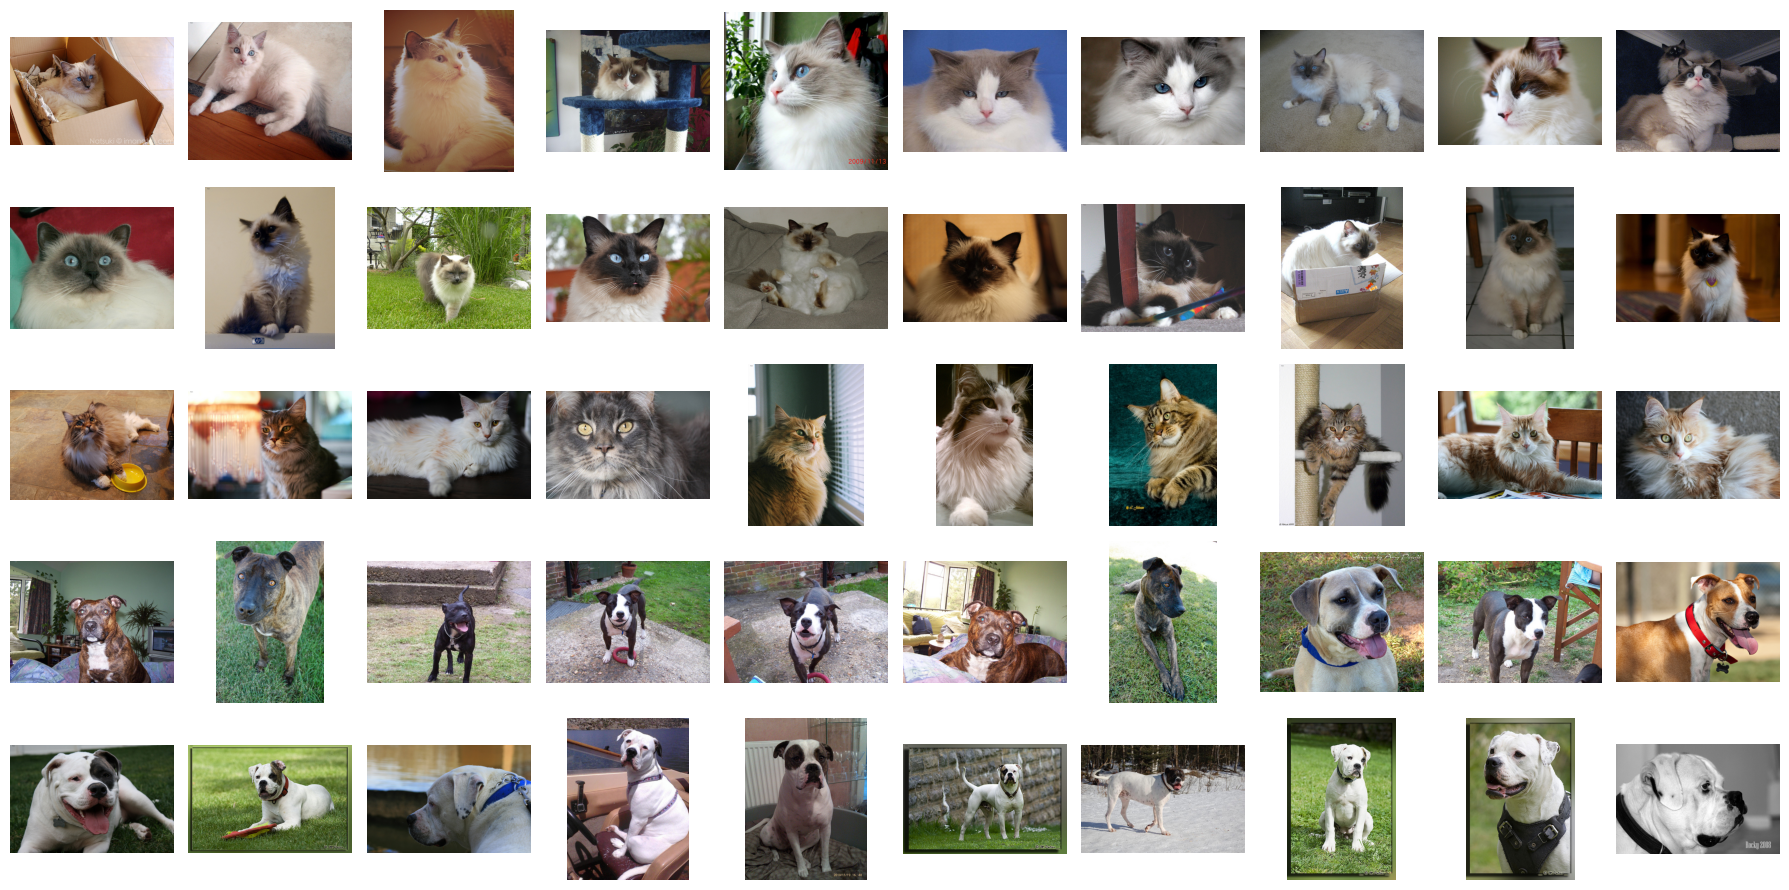

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(len(BREEDS_TO_TRAIN), N_IMAGES_PER_BREED, figsize=(N_IMAGES_PER_BREED * 1.8, len(BREEDS_TO_TRAIN) * 1.8))
for r, breed in enumerate(BREEDS_TO_TRAIN):
    imgs = sorted(Path(f'data/lora_train/{breed}').glob('*'))
    for c, p in enumerate(imgs[:N_IMAGES_PER_BREED]):
        ax = axes[r, c] if len(BREEDS_TO_TRAIN) > 1 else axes[c]
        ax.imshow(Image.open(p))
        ax.axis('off')
        if c == 0:
            ax.set_ylabel(breed, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Trening LoRA per klasa

In [8]:
import time

total_start = time.time()
for i, breed in enumerate(BREEDS_TO_TRAIN, 1):
    out_path = LORA_ROOT / breed / f'{breed}.safetensors'
    if out_path.exists():
        print(f'[{i}/{len(BREEDS_TO_TRAIN)}] {breed}: already trained, skip')
        continue
    print(f'\n[{i}/{len(BREEDS_TO_TRAIN)}] training LoRA for {breed}')
    start = time.time()
    !python scripts/train_lora.py \
        --breed {breed} \
        --train-data-dir data/lora_train/{breed} \
        --output-dir data/loras/{breed} \
        --steps {LORA_STEPS} \
        --rank {LORA_RANK} \
        --lr {LORA_LR}
    elapsed = (time.time() - start) / 60
    print(f'[{i}/{len(BREEDS_TO_TRAIN)}] {breed} done in {elapsed:.1f} min')

print(f'\ntotal: {(time.time()-total_start)/60:.1f} min')


[1/5] training LoRA for Ragdoll
device: cuda (Tesla T4, 15.6 GB)
breed: Ragdoll | prompt: a photo of <ragdoll> cat
training on 10 images
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
2026-05-25 07:06:41.510235: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
loading components...
tokenizer_config.json: 100% 806/806 [00:00<00:00, 6.12MB/s]
vocab.json: 1.06MB [00:00, 40.4MB/s]
merges.txt: 525kB [00:00, 144MB/s]
special_tokens_map.json: 100% 472/472 [00:00<00:00, 4.48MB/s]
config.json: 100% 617/617 [00:00<00:00, 5.68MB/s]
model.safetensors: 100% 4

## 6. Sanity check - wygeneruj po 4 obrazy z każdą LoRA

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


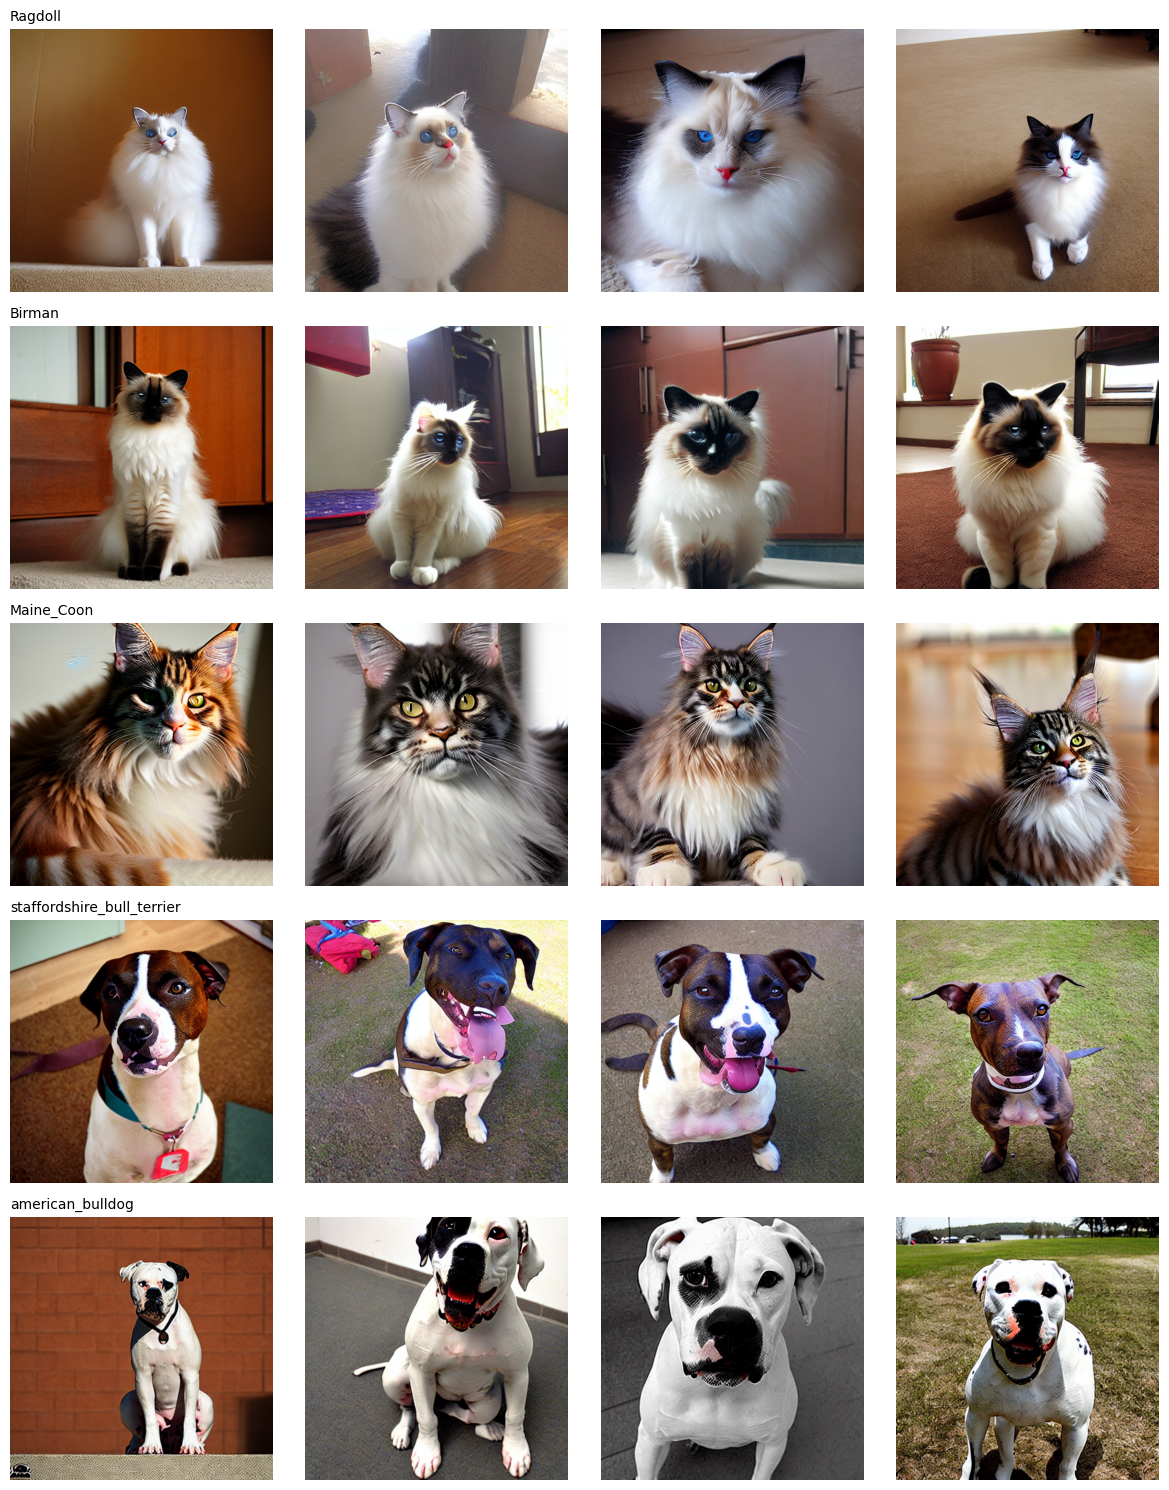

In [9]:
import torch
from diffusers import StableDiffusionPipeline
from src.synth.prompts import BREEDS, build_prompt
from src.utils.device import get_device

device = get_device()
dtype = torch.float16 if device.type == 'cuda' else torch.float32

pipe = StableDiffusionPipeline.from_pretrained('runwayml/stable-diffusion-v1-5', torch_dtype=dtype, safety_checker=None).to(device)
pipe.set_progress_bar_config(disable=True)

fig, axes = plt.subplots(len(BREEDS_TO_TRAIN), 4, figsize=(12, 3 * len(BREEDS_TO_TRAIN)))
for r, breed in enumerate(BREEDS_TO_TRAIN):
    lora_path = LORA_ROOT / breed / f'{breed}.safetensors'
    if not lora_path.exists():
        print(f'skip {breed}: no LoRA')
        continue
    pipe.unload_lora_weights()
    pipe.load_lora_weights(str(lora_path.parent), weight_name=lora_path.name)
    info = BREEDS[breed]
    prompt = f'a photo of {info.lora_trigger} {info.species}, sitting, looking at camera, high quality, detailed'
    seeds = [10, 11, 12, 13]
    generators = [torch.Generator(device=device.type).manual_seed(s) for s in seeds]
    imgs = pipe(prompt=[prompt]*4, num_inference_steps=30, guidance_scale=7.5, width=512, height=512, generator=generators).images
    for c, img in enumerate(imgs):
        ax = axes[r, c] if len(BREEDS_TO_TRAIN) > 1 else axes[c]
        ax.imshow(img)
        ax.axis('off')
        if c == 0:
            ax.set_title(breed, loc='left', fontsize=10)
plt.tight_layout(); plt.show()

## 7. Push LoRAs na HF

Wgrywa do `loras/<breed>.safetensors` w datasecie.

In [10]:
from huggingface_hub import HfApi, create_repo

create_repo(HF_REPO_ID, repo_type='dataset', exist_ok=True, private=True)
api = HfApi()
for breed in BREEDS_TO_TRAIN:
    p = LORA_ROOT / breed / f'{breed}.safetensors'
    if not p.exists():
        print(f'skip {breed}: no LoRA file')
        continue
    api.upload_file(
        path_or_fileobj=str(p),
        path_in_repo=f'loras/{breed}.safetensors',
        repo_id=HF_REPO_ID,
        repo_type='dataset',
        commit_message=f'LoRA SD 1.5 for {breed} (rank={LORA_RANK}, steps={LORA_STEPS})',
    )
    print(f'uploaded loras/{breed}.safetensors')
print(f'\nview: https://huggingface.co/datasets/{HF_REPO_ID}/tree/main/loras')

Ragdoll.safetensors:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

uploaded loras/Ragdoll.safetensors


Birman.safetensors:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

uploaded loras/Birman.safetensors


Maine_Coon.safetensors:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

uploaded loras/Maine_Coon.safetensors


staffordshire_bull_terrier.safetensors:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

uploaded loras/staffordshire_bull_terrier.safetensors


american_bulldog.safetensors:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

uploaded loras/american_bulldog.safetensors

view: https://huggingface.co/datasets/micwuj/dlicv-synth/tree/main/loras


In [ ]:
import shutil
shutil.make_archive('data', 'zip', '.', 'data')
from google.colab import files
files.download('data.zip')